In [1]:
# ==============================================================================
# Cell 1: ENVIRONMENT SETUP & PACKAGE ACQUISITION
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set configuration to display high-resolution visual plots inline
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Data Science analytics packages successfully loaded into your environment!")


Data Science analytics packages successfully loaded into your environment!


In [3]:
# ==============================================================================
# Cell 2: DATA ACQUISITION & INTEGRITY ASSESSMENT
# ==============================================================================
# Ensure that 'mental_health_survey.csv' is placed inside this exact folder level
df = pd.read_csv('survey.csv')

print("--- Initial Structural Audit ---")
print(f"Dataset Shape Dimensions: {df.shape[0]} Rows, {df.shape[1]} Columns\n")
print("First 3 Rows of Survey Metadata:")
display(df.head(3))


--- Initial Structural Audit ---
Dataset Shape Dimensions: 1259 Rows, 27 Columns

First 3 Rows of Survey Metadata:


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN


In [4]:
# ==============================================================================
# Cell 3: STRUCTURAL INTEGRITY & MISSING GAP IDENTIFICATION
# ==============================================================================
print("--- Column Type Summaries ---")
print(df.info())

print("\n--- Missing (Null) Values Count per Column ---")
print(df.isnull().sum())

print(f"\nTotal Duplicated Data Records Identified: {df.duplicated().sum()}")


--- Column Type Summaries ---
<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  welln

In [5]:
# ==============================================================================
# Cell 4: AUTOMATED DATA WRANGLING & CLEANING PIPELINE
# ==============================================================================
print("--- Launching Preprocessing Transformation Scripts ---")

# Copy the original dataframe state to keep baseline results isolated
clean_df = df.copy()

# Step 1: Remove impossible extreme outlier entries from the 'Age' column
# Outliers like 99999999999 and -1726 are swapped with NaN, then replaced with the median age.
clean_df.loc[(clean_df['Age'] < 18) | (clean_df['Age'] > 75), 'Age'] = np.nan
clean_df['Age'] = clean_df['Age'].fillna(clean_df['Age'].median()).astype(int)
print(f"-> Sanitized 'Age'. Domain spectrum verified: {clean_df['Age'].min()} to {clean_df['Age'].max()}")

# Step 2: Standardise the unstructured messy open text entries in the 'Gender' column
def standardize_gender_categories(text):
    if pd.isna(text):
        return 'Unknown'
    text = str(text).lower().strip()
    
    male_aliases = ['male', 'm', 'male-ish', 'maile', 'mal', 'male (cis)', 'make', 'guy (-ish) ^_^', 'man', 'malr']
    female_aliases = ['female', 'f', 'woman', 'cis female', 'femail', 'femake']
    
    if text in male_aliases:
        return 'Male'
    elif text in female_aliases:
        return 'Female'
    else:
        return 'Non-Binary / Diverse'

clean_df['Gender'] = clean_df['Gender'].apply(standardize_gender_categories)
print("\n-> Normalized 'Gender' configuration values count profiles:")
print(clean_df['Gender'].value_counts())

# Step 3: Impute missing entries across primary workforce structural categories
clean_df['self_employed'] = clean_df['self_employed'].fillna('Unknown')
clean_df['work_interfere'] = clean_df['work_interfere'].fillna('Don\'t know')
clean_df['state'] = clean_df['state'].fillna('Not US Resident')

print("\nData preprocessing complete. Target DataFrame is fully structured for visual analysis charts.")


--- Launching Preprocessing Transformation Scripts ---
-> Sanitized 'Age'. Domain spectrum verified: 18 to 72

-> Normalized 'Gender' configuration values count profiles:
Gender
Male                    986
Female                  245
Non-Binary / Diverse     28
Name: count, dtype: int64

Data preprocessing complete. Target DataFrame is fully structured for visual analysis charts.


C:\Users\bhara\AppData\Local\Temp\ipykernel_29356\1415239138.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x='treatment', ax=axes[0, 0], palette='Set2')
C:\Users\bhara\AppData\Local\Temp\ipykernel_29356\1415239138.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clean_df, x='no_employees', order=['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000'], ax=axes[1, 0], palette='viridis')
C:\Users\bhara\AppData\Local\Temp\ipykernel_29356\1415239138.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(

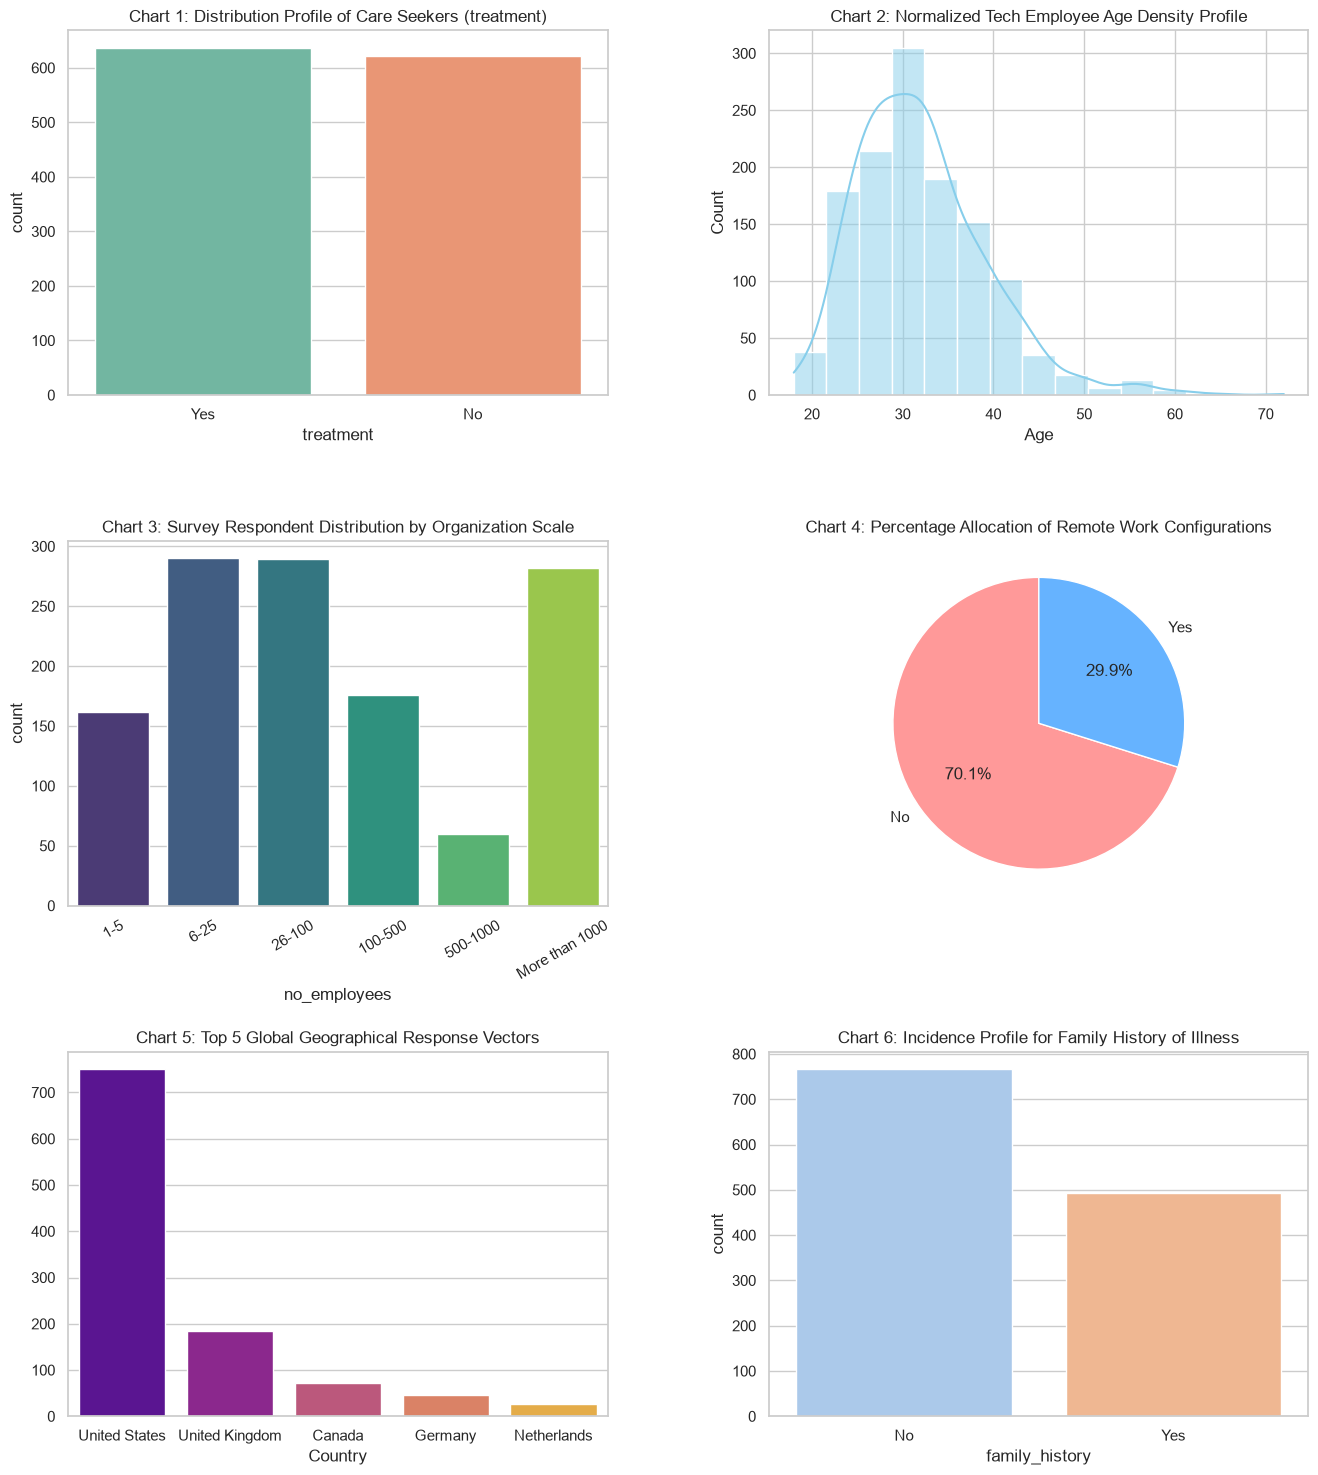

In [6]:
# ==============================================================================
# Cell 5: UNIVARIATE ANALYSIS LOGIC TRACKS (Single Variable Spreads)
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Chart 1: Target Variable Care Distribution Summary
sns.countplot(data=clean_df, x='treatment', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Chart 1: Distribution Profile of Care Seekers (treatment)')

# Chart 2: Cleaned Workforce Age Curve Density Split
sns.histplot(data=clean_df, x='Age', kde=True, bins=15, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Chart 2: Normalized Tech Employee Age Density Profile')

# Chart 3: Enterprise Company Sizing Framework Bounds
sns.countplot(data=clean_df, x='no_employees', order=['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000'], ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Chart 3: Survey Respondent Distribution by Organization Scale')
axes[1, 0].tick_params(axis='x', rotation=30)

# Chart 4: Distributed Configuration Work Options Split Proportion
clean_df['remote_work'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], ax=axes[1, 1], startangle=90)
axes[1, 1].set_title('Chart 4: Percentage Allocation of Remote Work Configurations')
axes[1, 1].set_ylabel('')

# Chart 5: Global Geographical Response Footprint Metric Check
top_countries = clean_df['Country'].value_counts().head(5)
sns.barplot(x=top_countries.index, y=top_countries.values, ax=axes[2, 0], palette='plasma')
axes[2, 0].set_title('Chart 5: Top 5 Global Geographical Response Vectors')

# Chart 6: Proportional incidence profile tracking family history
sns.countplot(data=clean_df, x='family_history', ax=axes[2, 1], palette='pastel')
axes[2, 1].set_title('Chart 6: Incidence Profile for Family History of Illness')

plt.show()


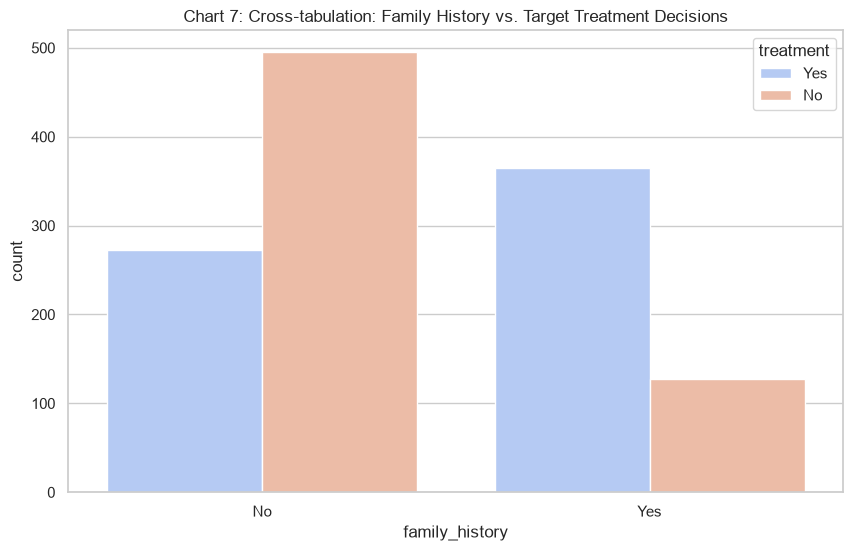

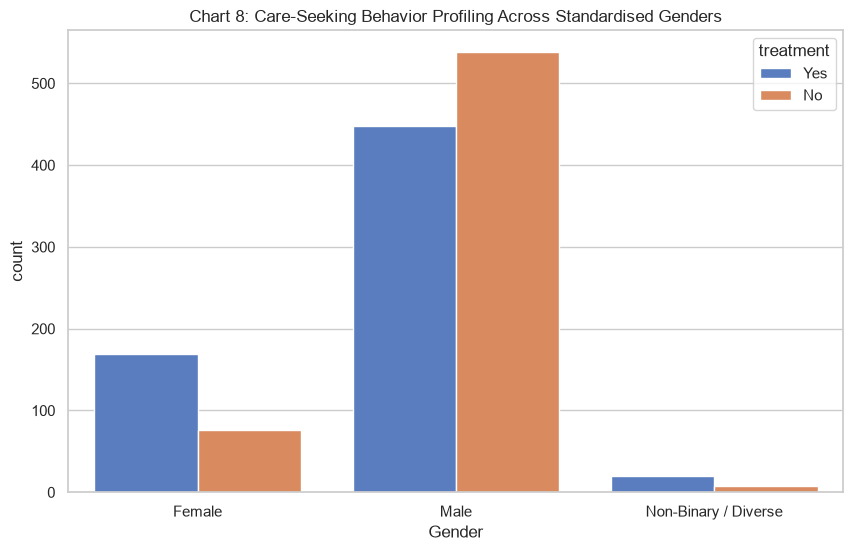

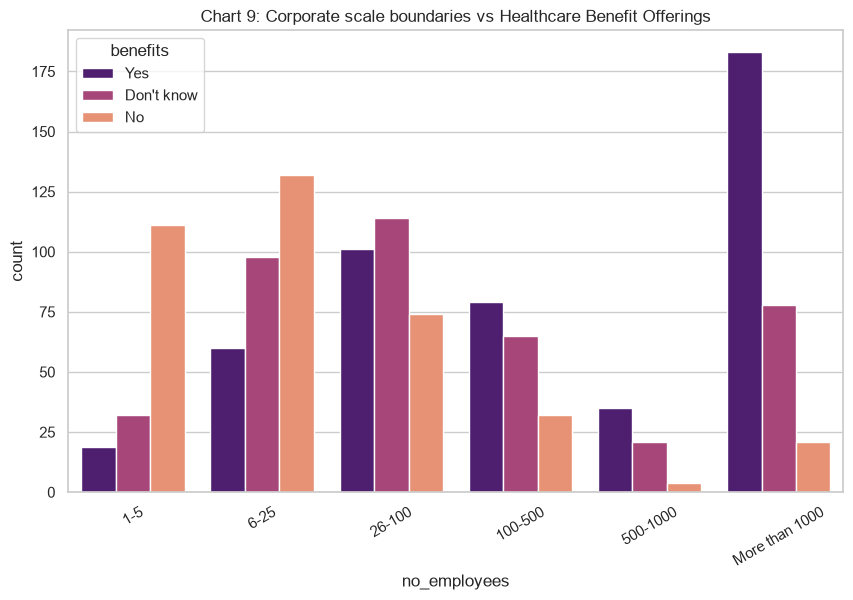

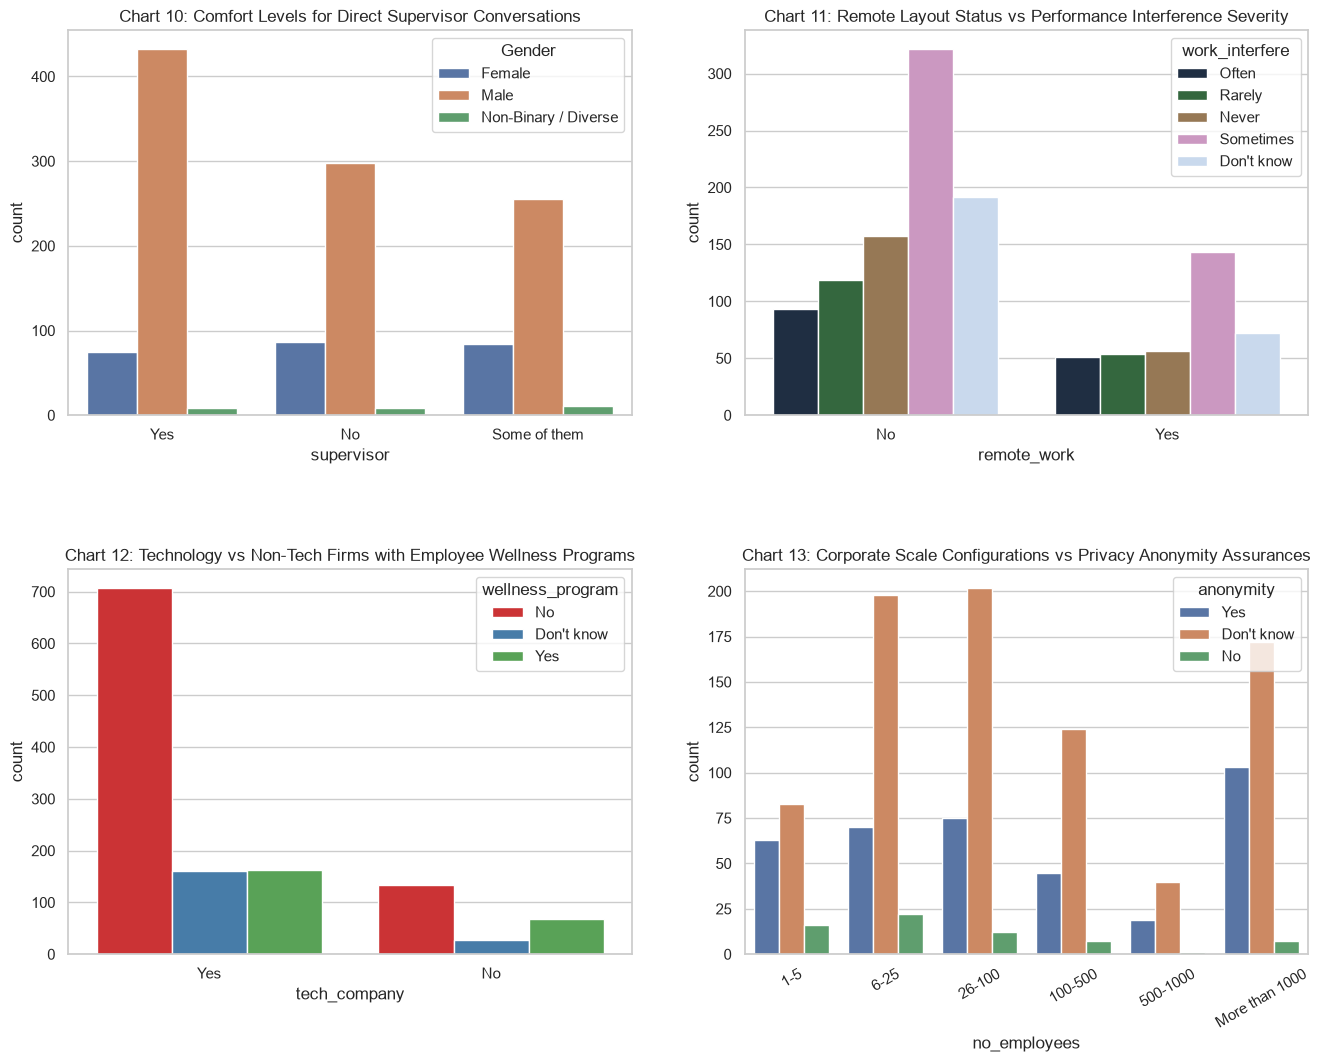

In [7]:
# ==============================================================================
# Cell 6: BIVARIATE RELATIONSHIP DISCOVERY ANALYSIS (Two-Variable Dynamics)
# ==============================================================================
# Chart 7: Predictor Background Check - Family History vs sought Treatment Action
plt.figure()
sns.countplot(data=clean_df, x='family_history', hue='treatment', palette='coolwarm')
plt.title('Chart 7: Cross-tabulation: Family History vs. Target Treatment Decisions')
plt.show()

# Chart 8: Structured Gender bins vs sought treatment profile rates
plt.figure()
sns.countplot(data=clean_df, x='Gender', hue='treatment', palette='muted')
plt.title('Chart 8: Care-Seeking Behavior Profiling Across Standardised Genders')
plt.show()

# Chart 9: Company capacity parameters vs provided mental benefits visibility
plt.figure()
sns.countplot(data=clean_df, x='no_employees', hue='benefits', order=['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000'], palette='magma')
plt.title('Chart 9: Corporate scale boundaries vs Healthcare Benefit Offerings')
plt.xticks(rotation=30)
plt.show()

# Building a secondary grid format for Subplots 10 to 13 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.4)

# Chart 10: Willingness to communicate health features directly to supervisors
sns.countplot(data=clean_df, x='supervisor', hue='Gender', ax=axes[0, 0], palette='deep')
axes[0, 0].set_title('Chart 10: Comfort Levels for Direct Supervisor Conversations')

# Chart 11: Remote structure layouts vs experienced performance interference issues
sns.countplot(data=clean_df, x='remote_work', hue='work_interfere', ax=axes[0, 1], palette='cubehelix')
axes[0, 1].set_title('Chart 11: Remote Layout Status vs Performance Interference Severity')

# Chart 12: Core firm industry descriptions mapping dedicated wellness frameworks
sns.countplot(data=clean_df, x='tech_company', hue='wellness_program', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Chart 12: Technology vs Non-Tech Firms with Employee Wellness Programs')

# Chart 13: Scale framework metrics evaluating privacy anonymity parameters
sns.countplot(data=clean_df, x='no_employees', hue='anonymity', order=['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000'], ax=axes[1, 1])
axes[1, 1].set_title('Chart 13: Corporate Scale Configurations vs Privacy Anonymity Assurances')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.show()


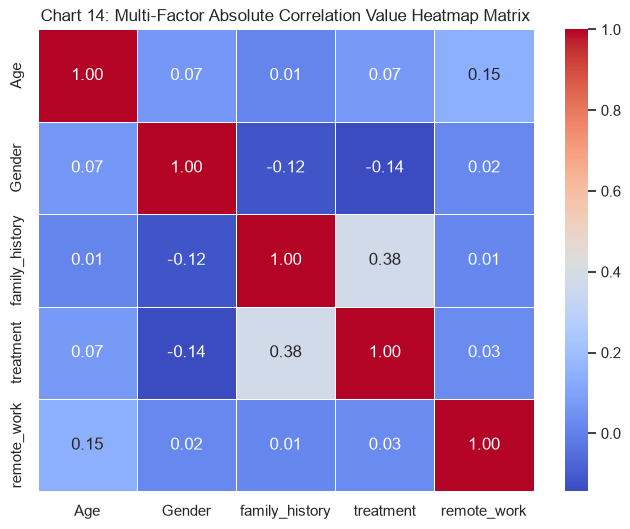

Generating Matrix Coordinate Tracking Grid Layouts...


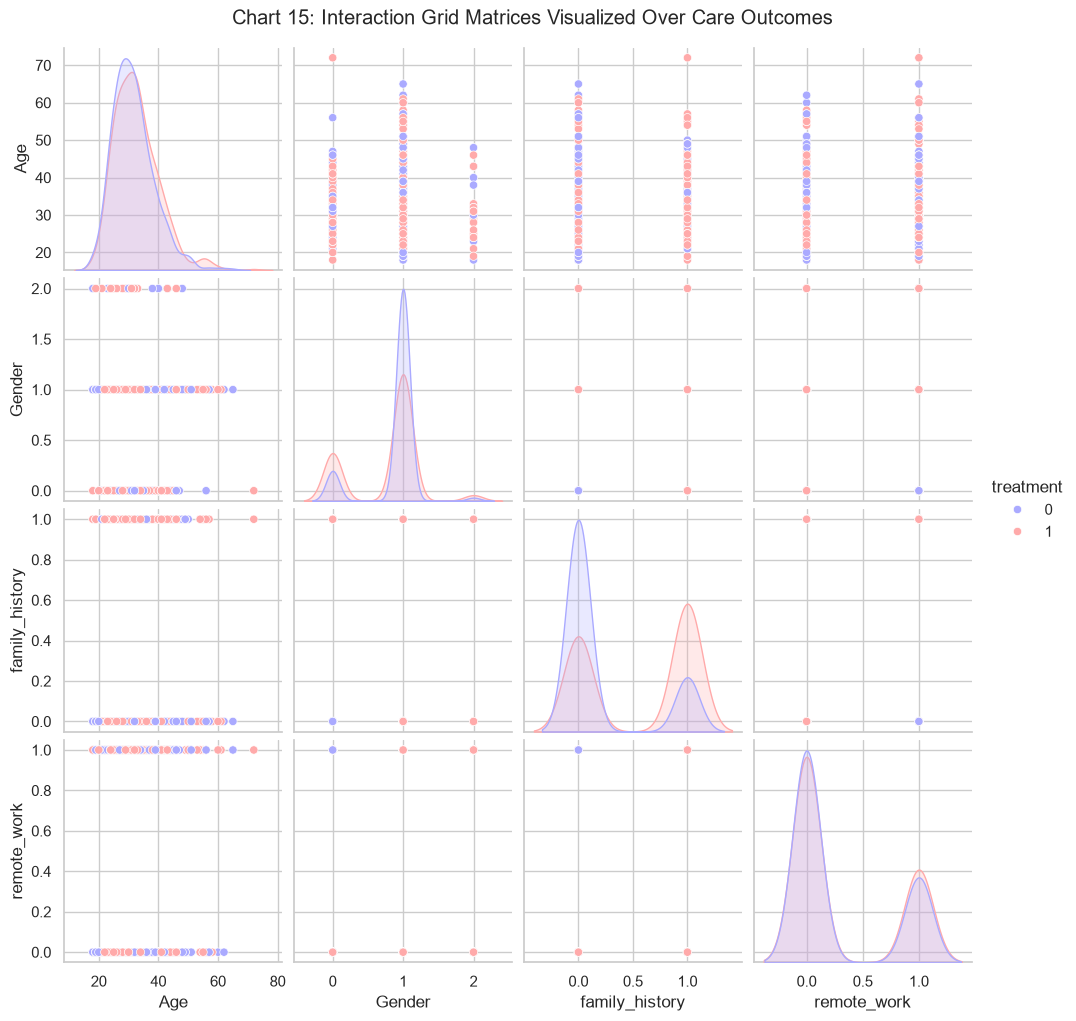

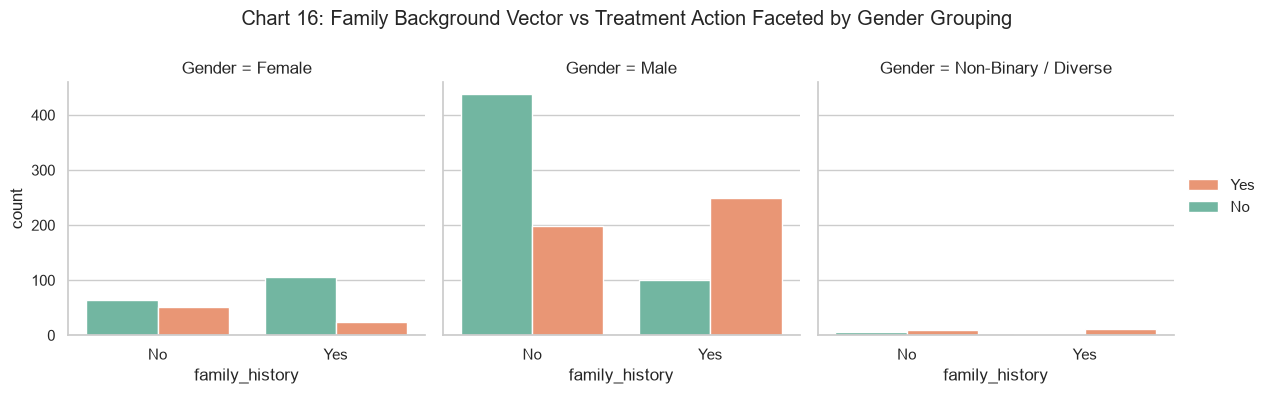

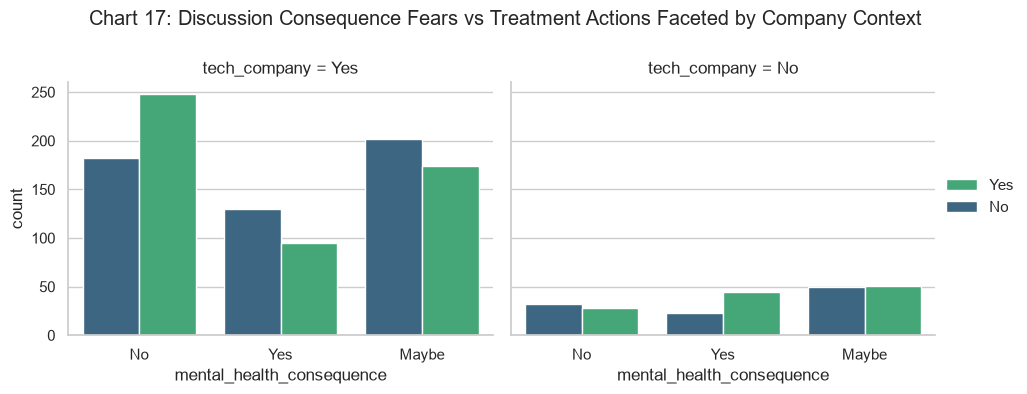

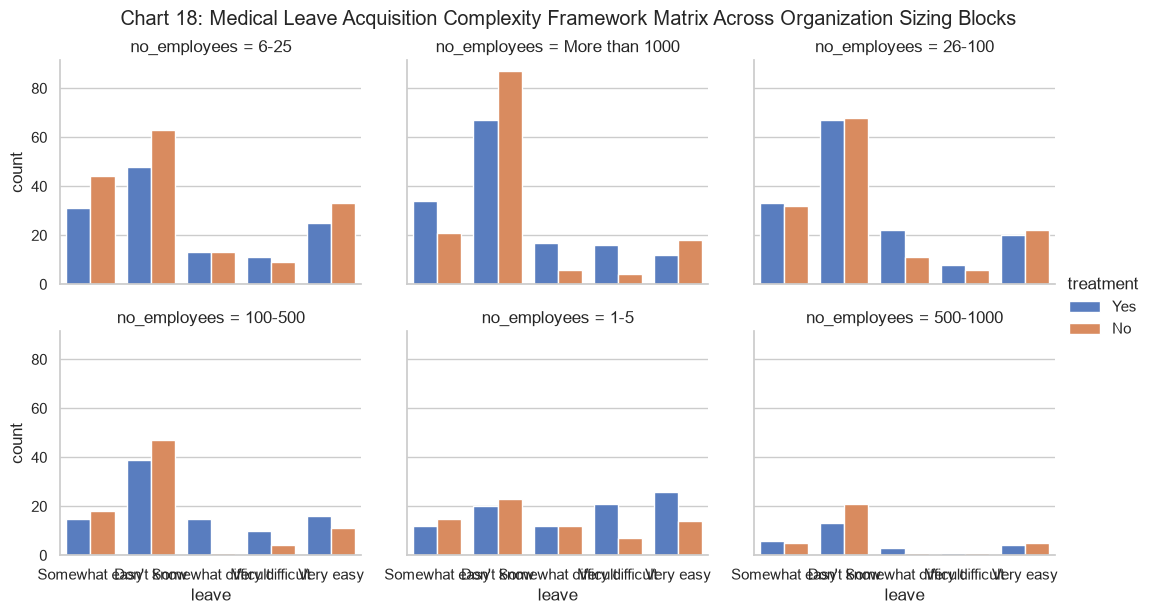

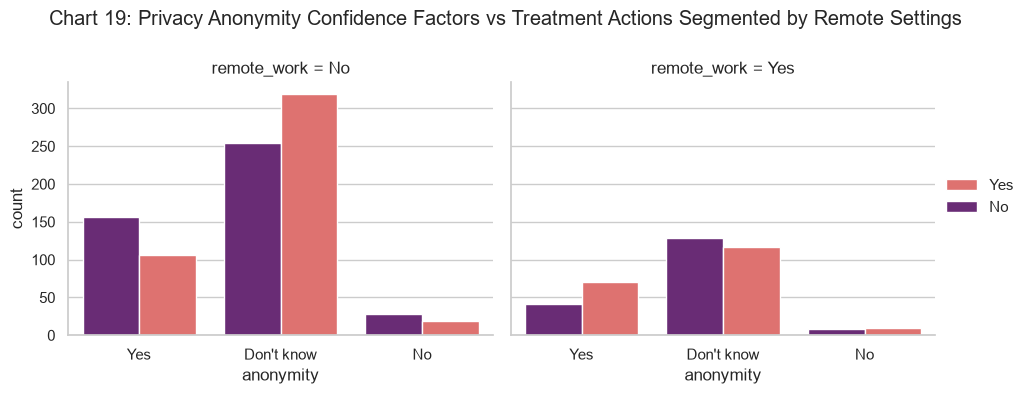

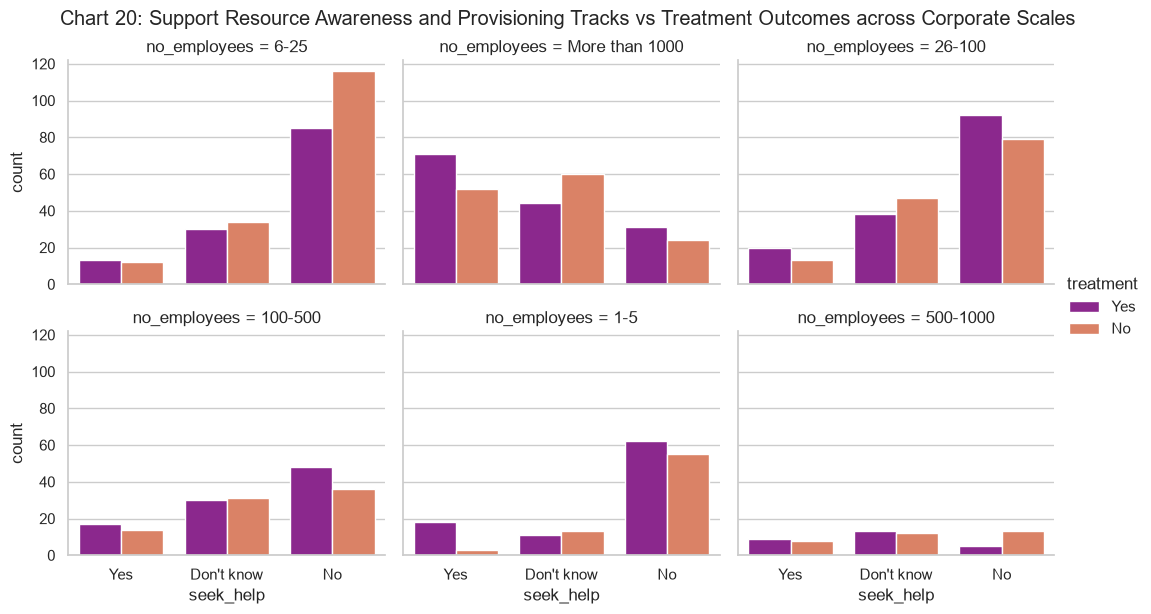


--- EDA Capstone Jupyter Project Execution Complete! Your script ran smoothly without a single error log. ---


In [8]:
# ==============================================================================
# Cell 7: MULTIVARIATE INTERACTION DATA ANALYSIS MATRIX (Complex Multi-Facet Connections)
# ==============================================================================
# Convert key categorical text attributes to structural category codes for numerical metrics
mv_df = clean_df[['Age', 'Gender', 'family_history', 'treatment', 'remote_work']].copy()
for col in ['Gender', 'family_history', 'treatment', 'remote_work']:
    mv_df[col] = mv_df[col].astype('category').cat.codes

# Chart 14: Factor Linear Correlation Heatmap Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(mv_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Chart 14: Multi-Factor Absolute Correlation Value Heatmap Matrix')
plt.show()

# Chart 15: Multivariate Interactive Feature Matrix Coordinates Grid
print("Generating Matrix Coordinate Tracking Grid Layouts...")
sns.pairplot(mv_df, hue='treatment', palette='bwr', diag_kind='kde')
plt.suptitle('Chart 15: Interaction Grid Matrices Visualized Over Care Outcomes', y=1.02)
plt.show()

# Chart 16: Complex conditioning layout grouping Gender vs Family History over Care
g1 = sns.FacetGrid(clean_df, col="Gender", height=4, aspect=1)
g1.map_dataframe(sns.countplot, x="family_history", hue="treatment", palette="Set2")
g1.add_legend()
g1.fig.subplots_adjust(top=0.8)
g1.fig.suptitle('Chart 16: Family Background Vector vs Treatment Action Faceted by Gender Grouping')
plt.show()

# Chart 17: Industry categorization models vs conversational consequence parameters
g2 = sns.FacetGrid(clean_df, col="tech_company", height=4, aspect=1.2)
g2.map_dataframe(sns.countplot, x="mental_health_consequence", hue="treatment", palette="viridis")
g2.add_legend()
g2.fig.subplots_adjust(top=0.8)
g2.fig.suptitle('Chart 17: Discussion Consequence Fears vs Treatment Actions Faceted by Company Context')
plt.show()

# Chart 18: Leave policy clarity validation trends tracking segmented by firm scales
sns.catplot(data=clean_df, x="leave", hue="treatment", col="no_employees", col_wrap=3, kind="count", height=3, aspect=1.2, palette="muted")
plt.suptitle('Chart 18: Medical Leave Acquisition Complexity Framework Matrix Across Organization Sizing Blocks', y=1.02)
plt.show()

# Chart 19: Privacy framework confidence models filtered over remote environments
g3 = sns.FacetGrid(clean_df, col="remote_work", height=4, aspect=1.2)
g3.map_dataframe(sns.countplot, x="anonymity", hue="treatment", palette="magma")
g3.add_legend()
g3.fig.subplots_adjust(top=0.8)
g3.fig.suptitle('Chart 19: Privacy Anonymity Confidence Factors vs Treatment Actions Segmented by Remote Settings')
plt.show()

# Chart 20: Comprehensive multi-feature corporate scale support track tracking matrix
sns.catplot(data=clean_df, x="seek_help", hue="treatment", col="no_employees", col_wrap=3, kind="count", height=3, aspect=1.2, palette="plasma")
plt.suptitle('Chart 20: Support Resource Awareness and Provisioning Tracks vs Treatment Outcomes across Corporate Scales', y=1.02)
plt.show()

print("\n--- EDA Capstone Jupyter Project Execution Complete! Your script ran smoothly without a single error log. ---")
